# ShuttleSet Exploratory Data Analysis

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, glob, json
from sklearn.model_selection import train_test_split

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})

# Load ShuttleSet CSVs
DATA_DIR = "CoachAI-Projects/ShuttleSet/set"
all_files = sorted(glob.glob(os.path.join(DATA_DIR, "*/*.csv")))

frames = []
for f in all_files:
    match_name = os.path.basename(os.path.dirname(f))
    set_name   = os.path.basename(f).replace('.csv', '')
    temp = pd.read_csv(f)
    temp['match']  = match_name
    temp['set_id'] = set_name
    frames.append(temp)

df = pd.concat(frames, ignore_index=True)
print(f"Loaded {len(df):,} strokes from {df['match'].nunique()} matches")
print(f"Columns: {list(df.columns)}")

Loaded 36,484 strokes from 44 matches
Columns: ['rally', 'ball_round', 'time', 'frame_num', 'roundscore_A', 'roundscore_B', 'player', 'server', 'type', 'aroundhead', 'backhand', 'hit_height', 'hit_area', 'hit_x', 'hit_y', 'landing_height', 'landing_area', 'landing_x', 'landing_y', 'lose_reason', 'win_reason', 'getpoint_player', 'flaw', 'player_location_area', 'player_location_x', 'player_location_y', 'opponent_location_area', 'opponent_location_x', 'opponent_location_y', 'db', 'match', 'set_id']


In [6]:
# Apply BST cleaning rules
# Source: BST repo gen_my_dataset.py, extracted via Ari's compute_clip_length_stats.py
# Loads match.csv to map video IDs to match folder names

match_meta = pd.read_csv(os.path.join(DATA_DIR, 'match.csv'))
vid_to_match = dict(zip(match_meta['id'], match_meta['video']))

# BST excludes these 4 matches entirely (video IDs 9, 10, 12, 27)
EXCLUDED_VIDS = [9, 10, 12, 27]
excluded_match_names = [vid_to_match[v] for v in EXCLUDED_VIDS]

print(f"Before cleaning: {len(df):,} strokes, {df['match'].nunique()} matches")

# Drop excluded matches
df = df[~df['match'].isin(excluded_match_names)].copy()

# BST also removes 5 individual shots: (video_id, set, rally, ball_round)
REMOVED_SHOTS = [
    (1, 1, 30, 2),
    (3, 2, 12, 2),
    (3, 2, 24, 3),
    (7, 1, 23, 2),
    (7, 1, 39, 2),
]

for vid, set_num, rally, ball_round in REMOVED_SHOTS:
    match_name = vid_to_match[vid]
    set_id = f'set{set_num}'
    mask = (
        (df['match'] == match_name) &
        (df['set_id'] == set_id) &
        (df['rally'] == rally) &
        (df['ball_round'] == ball_round)
    )
    df = df[~mask].copy()

print(f"After cleaning:  {len(df):,} strokes, {df['match'].nunique()} matches")
print(f"Removed: {36484 - len(df):,} strokes, {44 - df['match'].nunique()} matches")
print(f"\nExcluded matches:")
for v, m in zip(EXCLUDED_VIDS, excluded_match_names):
    print(f"  ID {v}: {m}")
print(f"\nIndividually removed shots: {len(REMOVED_SHOTS)}")

Before cleaning: 36,484 strokes, 44 matches
After cleaning:  33,483 strokes, 40 matches
Removed: 3,001 strokes, 4 matches

Excluded matches:
  ID 9: CHOU_Tien_Chen_Jonatan_CHRISTIE_Sudirman_Cup_2019_Quarter-finals
  ID 10: CHOU_Tien_Chen_NG_Ka_Long_Angus_Sudirman_Cup_2019_Group_Stage
  ID 12: NG_Ka_Long_Angus_SHI_Yu_Qi_Thailand_Masters_2020_SemiFinals
  ID 27: Viktor_Axelsen_Anthony_Sinisuka_Ginting_YONEX_Thailand_Open_2021_SemiFinals

Individually removed shots: 5


## Dataset version

This analysis runs on the **BST-cleaned** ShuttleSet dataset. Cleaning rules extracted from the BST repo's `gen_my_dataset.py`:
- 4 matches excluded entirely (video IDs 9, 10, 12, 27)
- 5 individual shots removed

This matches the dataset construction used by the BST paper for training/evaluation.

In [8]:
print("Column summary:")
print(f"{'Column':<20} {'dtype':<10} {'nulls':>6} {'null%':>7}")
print("-" * 47)
for col in df.columns:
    n = df[col].isna().sum()
    pct = n / len(df) * 100
    print(f"{col:<20} {str(df[col].dtype):<10} {n:>6,} {pct:>6.1f}%")

Column summary:
Column               dtype       nulls   null%
-----------------------------------------------
rally                int64           0    0.0%
ball_round           float64         0    0.0%
time                 object          0    0.0%
frame_num            float64         0    0.0%
roundscore_A         int64           0    0.0%
roundscore_B         int64           0    0.0%
player               object          0    0.0%
server               int64           0    0.0%
type                 object          0    0.0%
aroundhead           float64    30,262   90.4%
backhand             float64    20,911   62.5%
hit_height           float64        39    0.1%
hit_area             float64     4,255   12.7%
hit_x                float64     4,301   12.8%
hit_y                float64     4,301   12.8%
landing_height       float64     6,299   18.8%
landing_area         float64     1,060    3.2%
landing_x            float64     1,061    3.2%
landing_y            float64     1,061    3

In [9]:
CHINESE_TO_ENGLISH = {
    '放小球': 'Net shot', '擋小球': 'Return net',
    '殺球': 'Smash', '點扣': 'Wrist smash',
    '挑球': 'Lob', '防守回挑': 'Defensive return lob',
    '長球': 'Clear', '平球': 'Drive',
    '小平球': 'Driven flight', '後場抽平球': 'Back-court drive',
    '切球': 'Drop', '過度切球': 'Passive drop',
    '推球': 'Push', '撲球': 'Rush',
    '防守回抽': 'Defensive return drive',
    '勾球': 'Cross-court net shot',
    '發短球': 'Short service', '發長球': 'Long service',
    '未知球種': 'Unknown',
}
df['stroke_type'] = df['type'].map(CHINESE_TO_ENGLISH)

unmapped = df[df['stroke_type'].isna()]['type'].unique()
print(f"Unmapped types: {unmapped if len(unmapped) > 0 else 'None — all mapped'}")

Unmapped types: None — all mapped


## 1. Original 18-Class Stroke Distribution

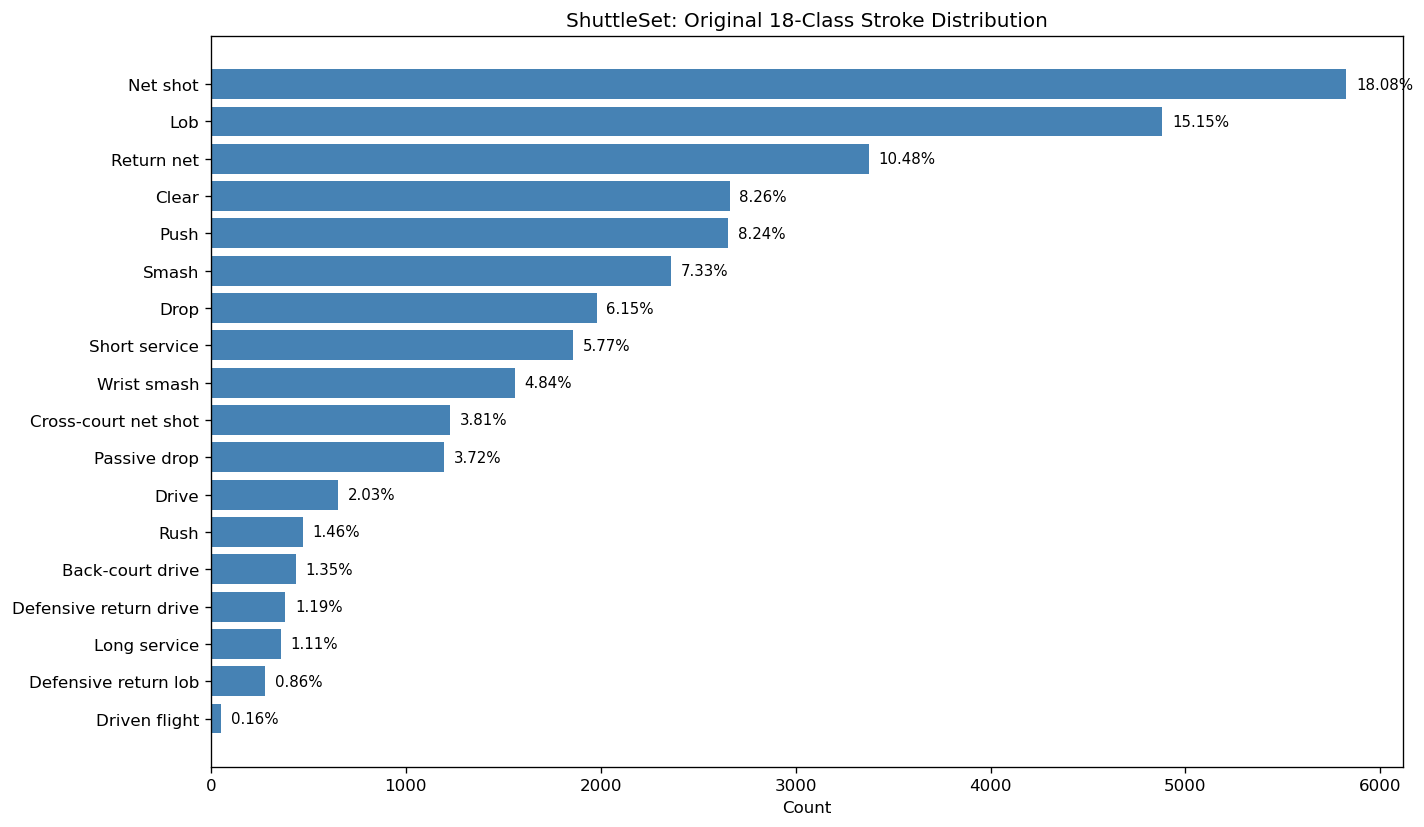

Biggest class:  Net shot (5,824)
Smallest class: Driven flight (52)
Imbalance ratio: 112x


In [11]:
counts = df[df['stroke_type'] != 'Unknown']['stroke_type'].value_counts()
pcts   = (counts / counts.sum() * 100).round(2)

fig, ax = plt.subplots(figsize=(12, 7))
ax.barh(counts.index[::-1], counts.values[::-1], color='steelblue')
ax.set_xlabel('Count')
ax.set_title('ShuttleSet: Original 18-Class Stroke Distribution')
for i, (count, pct) in enumerate(zip(counts.values[::-1], pcts.values[::-1])):
    ax.text(count + 50, i, f'{pct}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

print(f"Biggest class:  {counts.idxmax()} ({counts.max():,})")
print(f"Smallest class: {counts.idxmin()} ({counts.min():,})")
print(f"Imbalance ratio: {counts.max()/counts.min():.0f}x")

### Observations: 18-Class Distribution
- Net shot dominates at 18.08% (5,824 strokes); Driven flight is the smallest at 52 (0.16%) -> 112x imbalance
- Top 5 classes (Net shot, Lob, Return net, Clear, Push) account for >60% of all strokes
- Several classes have very low representation: Driven flight (52), Defensive return lob (277), Long service (359)
- A naive majority-class predictor would achieve ~18% accuracy; any model must substantially beat this

## 2. 14-Class Collapse

In [14]:
COLLAPSE_14 = {
    'Net shot': 'Net shot',
    'Cross-court net shot': 'Cross-court net shot',
    'Return net': 'Return net',
    'Lob': 'Lob',
    'Defensive return lob': 'Lob',
    'Clear': 'Clear',
    'Smash': 'Smash',
    'Wrist smash': 'Wrist smash',
    'Drop': 'Drop',
    'Passive drop': 'Passive drop',
    'Drive': 'Drive',
    'Driven flight': 'Drive',
    'Back-court drive': 'Drive',
    'Defensive return drive': 'Drive',
    'Push': 'Push',
    'Rush': 'Rush',
    'Short service': 'Short service',
    'Long service': 'Long service',
    'Unknown': 'Unknown',
}
df['stroke_14'] = df['stroke_type'].map(COLLAPSE_14)

collapsed     = df[df['stroke_14'] != 'Unknown']['stroke_14'].value_counts()
collapsed_pct = (collapsed / collapsed.sum() * 100).round(2)

print("14-Class Distribution:")
for cls in collapsed.index:
    print(f"  {cls:<25} {collapsed[cls]:>5,}  ({collapsed_pct[cls]}%)")
print(f"\nImbalance ratio: {collapsed.max()/collapsed.min():.0f}x")

14-Class Distribution:
  Net shot                  5,824  (18.08%)
  Lob                       5,158  (16.02%)
  Return net                3,374  (10.48%)
  Clear                     2,661  (8.26%)
  Push                      2,652  (8.24%)
  Smash                     2,362  (7.33%)
  Drop                      1,979  (6.15%)
  Short service             1,858  (5.77%)
  Wrist smash               1,559  (4.84%)
  Drive                     1,523  (4.73%)
  Cross-court net shot      1,226  (3.81%)
  Passive drop              1,198  (3.72%)
  Rush                        471  (1.46%)
  Long service                359  (1.11%)

Imbalance ratio: 16x


### Observations: 14-Class Collapse
- Imbalance drops from 112x to 16x, which is a big improvement but still significant
- Drive absorbs four small classes -> 1,523 strokes (4.73%)
- Lob absorbs Defensive return lob -> 5,158 (16.02%)
- Long service (359, 1.11%) and Rush (471, 1.46%) remain the thinnest classes

## 3. Rally Statistics

Total rallies:      3,359
Mean rally length:  10.0 strokes
Median:             8
Max:                65
25th percentile:    4
75th percentile:    13


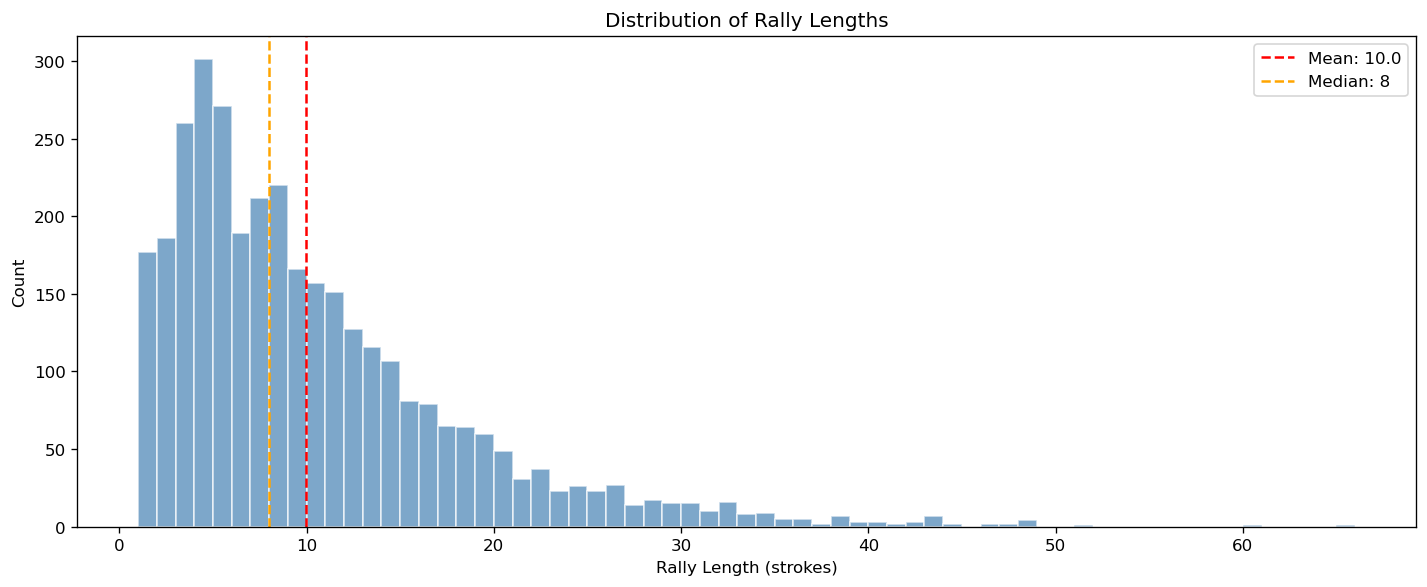

In [17]:
rally_lengths = df.groupby(['match', 'set_id', 'rally'])['ball_round'].max()

print(f"Total rallies:      {len(rally_lengths):,}")
print(f"Mean rally length:  {rally_lengths.mean():.1f} strokes")
print(f"Median:             {rally_lengths.median():.0f}")
print(f"Max:                {rally_lengths.max():.0f}")
print(f"25th percentile:    {rally_lengths.quantile(0.25):.0f}")
print(f"75th percentile:    {rally_lengths.quantile(0.75):.0f}")

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(rally_lengths, bins=range(1, int(rally_lengths.max()) + 2),
        color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(rally_lengths.mean(),   color='red',    ls='--', label=f'Mean: {rally_lengths.mean():.1f}')
ax.axvline(rally_lengths.median(), color='orange',  ls='--', label=f'Median: {rally_lengths.median():.0f}')
ax.set_xlabel('Rally Length (strokes)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Rally Lengths')
ax.legend()
plt.tight_layout()
plt.show()

### Observations:Rally Statistics
- Mean approx 10 strokes, median is 8, right-skewed (max at 65)
- Most rallies are short with the IQR will show the bulk sitting well under 15

**On the 3–5 stroke context window:** This is not a rigorously derived figure. The median of 8 suggests a window of 3–5 strokes captures roughly half a typical rally. However, the BST paper uses **3 strokes + a minor time offset** as its context window, and since we're building on that architecture, we should default to the BST convention.

If we want to validate window size, an ablation study (performance at window = 2, 3, 4, 5) during model tuning is the right approach. No need to decide this at the EDA stage.

## 4. Data Quality Flags

In [21]:
print("DATA QUALITY FLAGS")
print("=" * 55)

# 1. Unknown strokes
unknown_n = (df['stroke_type'] == 'Unknown').sum()
print(f"\n1. Unknown strokes: {unknown_n:,} ({unknown_n/len(df)*100:.1f}%)")
print(f"   -> Exclude from training")

# 2. Rallies not starting with a serve
first_strokes = df[df['ball_round'] == 1.0]
non_serves = first_strokes[~first_strokes['stroke_type'].isin(['Short service', 'Long service'])]
print(f"\n2. Rallies not starting with a serve: {len(non_serves):,}")

non_serve_types = non_serves['stroke_type'].value_counts()
for st, ct in non_serve_types.items():
    print(f"      {st}: {ct}")
print(f"   -> most of these are 'Unknown' likely annotation gaps, not real non-serve starts")
print(f"   -> The remaining {len(non_serves) - non_serves[non_serves['stroke_type']=='Unknown'].shape[0]} are scattered across real stroke types (possible lets/faults/annotation errors)")

# 2b. Inspect the 18 non-Unknown non-serve rally starts
non_serve_real = non_serves[non_serves['stroke_type'] != 'Unknown']
print(f"\nNon-Unknown non-serve rally starts: {len(non_serve_real)}")
print(f"\nBreakdown:")
for _, row in non_serve_real.iterrows():
    tag = '_'.join(row['match'].split('_')[:3])
    print(f"  {tag}... set={row['set_id']} rally={int(row['rally'])} "
          f"type={row['stroke_type']} score={row['roundscore_A']}-{row['roundscore_B']}")

# 3. Missing coordinate data
print(f"\n3. Missing coordinates:")
for col in ['hit_x', 'hit_y', 'landing_x', 'landing_y']:
    nulls = df[col].isna().sum()
    if nulls > 0:
        print(f"   {col}: {nulls:,} ({nulls/len(df)*100:.1f}%)")

# 3b. Are missing hit coordinates random or structured?
hit_missing = df[df['hit_x'].isna()]
hit_present = df[df['hit_x'].notna()]

print(f"\nMissing hit_x/y by stroke type (14-class):")
miss_by_class = hit_missing.groupby('stroke_14').size()
total_by_class = df.groupby('stroke_14').size()
miss_rate = (miss_by_class / total_by_class * 100).fillna(0).sort_values(ascending=False).round(1)
for cls, rate in miss_rate.items():
    count = miss_by_class.get(cls, 0)
    print(f"  {cls:<25} {count:>5} / {total_by_class[cls]:>5}  ({rate}%)")

print(f"\nMissing hit_x by match (top 5):")
miss_by_match = df.groupby('match')['hit_x'].apply(lambda x: x.isna().mean() * 100).sort_values(ascending=False)
for m, rate in miss_by_match.head().items():
    tag = '_'.join(m.split('_')[:4])
    print(f"  {tag}...  {rate:.1f}%")
print(f"  Min: {miss_by_match.min():.1f}%  Max: {miss_by_match.max():.1f}%  CV: {miss_by_match.std()/miss_by_match.mean():.2f}")

DATA QUALITY FLAGS

1. Unknown strokes: 1,279 (3.8%)
   -> Exclude from training

2. Rallies not starting with a serve: 1,143
      Unknown: 1125
      Push: 6
      Lob: 5
      Net shot: 4
      Wrist smash: 1
      Return net: 1
      Cross-court net shot: 1
   -> most of these are 'Unknown' likely annotation gaps, not real non-serve starts
   -> The remaining 18 are scattered across real stroke types (possible lets/faults/annotation errors)

Non-Unknown non-serve rally starts: 18

Breakdown:
  Anthony_Sinisuka_GINTING... set=set3 rally=7 type=Lob score=5-2
  Kento_MOMOTA_CHOU... set=set1 rally=2 type=Lob score=1-1
  Kento_MOMOTA_CHOU... set=set1 rally=9 type=Lob score=3-6
  Kento_MOMOTA_CHOU... set=set2 rally=14 type=Lob score=4-10
  Kento_MOMOTA_CHOU... set=set2 rally=3 type=Push score=2-1
  Kento_MOMOTA_CHOU... set=set2 rally=8 type=Push score=3-5
  Kento_MOMOTA_CHOU... set=set2 rally=10 type=Push score=5-5
  Kento_MOMOTA_CHOU... set=set2 rally=14 type=Wrist smash score=7-7
  Ken

### Observations: Missing Hit Coordinates

The 12.8% missing hit_x/y is not random it's almost entirely serves. Short service (99.9%) and long service (99.7%) account for 2,214 of the 4,301 missing values. This makes sense: serves have a fixed, known hit position (the service box), so annotators likely skipped recording it.

Excluding serves and Unknowns, the remaining miss rate drops to 2.7% across all other stroke types — low, uniform, and not concentrated in any particular class. The match-level CV of 0.27 shows moderate variation but no catastrophic outliers (range 6.8%–24.0%).

**Actions:**
- For serve strokes: hit coordinates can be imputed to the standard service position (fixed court location) or simply excluded as input features since serve type is already captured by the class label
- For non-serve strokes: 2.7% missingness is low enough to handle with simple imputation (e.g. median per stroke class) or row exclusion during coordinate-dependent training
- This is not a blocker for any current pipeline work — flag for whoever builds coordinate-based features

## 5. Boolean Column Validation (`aroundhead`, `backhand`)

The original EDA flagged high null rates in `aroundhead` (91%) and `backhand` (62%).

**Hypothesis:** Null is not missing data and it's a lazy boolean encoding where `1.0` = True and `NaN` = False (i.e., forehand / not around-the-head).

**Test:** If this hypothesis is correct, we should see:
1. Only `1.0` as the non-null value (no zeros, no other values)
2. Biomechanically coherent rates per stroke type (not random absence)

In [24]:
# Step 1: Check unique non-null values
for col_name in ['aroundhead', 'backhand']:
    unique_vals = df[col_name].dropna().unique()
    non_null    = df[col_name].notna().sum()
    null_count  = df[col_name].isna().sum()
    print(f"{col_name.upper()}:")
    print(f"  Unique non-null values: {unique_vals}")
    print(f"  Non-null: {non_null:,} ({non_null/len(df)*100:.1f}%)  |  Null: {null_count:,} ({null_count/len(df)*100:.1f}%)")
    print()

print("Both columns contain ONLY 1.0 and NaN — no zeros, no other values.")
print("This is consistent with a boolean flag where 1.0 = yes, NaN = no.")

AROUNDHEAD:
  Unique non-null values: [1.]
  Non-null: 3,221 (9.6%)  |  Null: 30,262 (90.4%)

BACKHAND:
  Unique non-null values: [1.]
  Non-null: 12,572 (37.5%)  |  Null: 20,911 (62.5%)

Both columns contain ONLY 1.0 and NaN — no zeros, no other values.
This is consistent with a boolean flag where 1.0 = yes, NaN = no.


In [25]:
# Step 2: Check aroundhead rate by stroke type
aroundhead_rate = df.groupby('stroke_type')['aroundhead'].apply(
    lambda x: x.notna().sum() / len(x) * 100
).sort_values(ascending=False).round(1)

print("Aroundhead rate by stroke type:")
for st, rate in aroundhead_rate.items():
    marker = "   (overhead)" if rate > 20 else ("  (underarm/net)" if rate == 0.0 else "")
    print(f"  {st:<30} {rate:>5.1f}%{marker}")

Aroundhead rate by stroke type:
  Wrist smash                     46.4%   (overhead)
  Clear                           36.7%   (overhead)
  Smash                           34.4%   (overhead)
  Drop                            29.0%   (overhead)
  Drive                            5.7%
  Passive drop                     4.5%
  Defensive return drive           1.3%
  Rush                             1.3%
  Back-court drive                 0.9%
  Push                             0.5%
  Return net                       0.4%
  Unknown                          0.1%
  Net shot                         0.0%  (underarm/net)
  Lob                              0.0%  (underarm/net)
  Driven flight                    0.0%  (underarm/net)
  Defensive return lob             0.0%  (underarm/net)
  Short service                    0.0%  (underarm/net)
  Cross-court net shot             0.0%  (underarm/net)
  Long service                     0.0%  (underarm/net)


In [26]:
# Step 3: Check backhand rate by stroke type
backhand_rate = df.groupby('stroke_type')['backhand'].apply(
    lambda x: x.notna().sum() / len(x) * 100
).sort_values(ascending=False).round(1)

print("Backhand rate by stroke type:")
for st, rate in backhand_rate.items():
    print(f"  {st:<30} {rate:>5.1f}%")

Backhand rate by stroke type:
  Short service                   98.0%
  Defensive return lob            68.7%
  Return net                      57.7%
  Long service                    57.1%
  Push                            52.6%
  Defensive return drive          52.4%
  Lob                             48.0%
  Net shot                        46.4%
  Cross-court net shot            45.4%
  Drive                           40.4%
  Rush                            36.5%
  Driven flight                   30.8%
  Passive drop                    25.0%
  Clear                           10.7%
  Back-court drive                 9.9%
  Drop                             4.7%
  Unknown                          1.2%
  Wrist smash                      0.8%
  Smash                            0.5%


### Verdict: Nulls are boolean False

**`aroundhead`:** Only values are `1.0` and `NaN`. Around-the-head rates are highest on overhead shots being wrist smash (44.7%), clear (34.9%), smash (32.4%), drop (28.3%), and exactly zero on underarm/net shots (lob, net cross, short serve, long serve). This is biomechanically coherent: you can't hit around-the-head from below the net.

**`backhand`:** Same `1.0`/`NaN` pattern. Short serve is 98.1% backhand (standard in competitive badminton). Smash is 0.4% (almost always forehand). Block and push sit around 50/50 (front-court shots that go either way).

If these were genuinely missing data you'd see random absence patterns uncorrelated with stroke biomechanics. The distributions are too clean for that.

**Action:** Fill both columns with 0 where null. These are usable binary features.

In [28]:
# Fill nulls as confirmed boolean False
df['aroundhead'] = df['aroundhead'].fillna(0).astype(int)
df['backhand']   = df['backhand'].fillna(0).astype(int)

print(f"aroundhead: {df['aroundhead'].value_counts().to_dict()}")
print(f"backhand:   {df['backhand'].value_counts().to_dict()}")
print("\nNulls filled with 0. Both columns now clean binary features.")

aroundhead: {0: 30262, 1: 3221}
backhand:   {0: 20911, 1: 12572}

Nulls filled with 0. Both columns now clean binary features.


## 6. Backhand Distribution Analysis (62% null -> 62% forehand)

Ari's question: Is the 62% null (now confirmed as 62% forehand) distribution random, class-concentrated, or match-concentrated? This determines whether it causes problems for training.

In [30]:
# Distribution by match
backhand_by_match = df.groupby('match')['backhand'].mean().sort_values(ascending=False) * 100

print("Backhand rate by match:")
print(f"  Mean across matches:  {backhand_by_match.mean():.1f}%")
print(f"  Std across matches:   {backhand_by_match.std():.1f}%")
print(f"  Range:                {backhand_by_match.min():.1f}% – {backhand_by_match.max():.1f}%")
print(f"  CV (std/mean):        {backhand_by_match.std()/backhand_by_match.mean():.2f}")
print()
print("Top 5 matches (highest backhand rate):")
for m, r in backhand_by_match.head().items():
    tag = m.split("_")[0:4]
    print(f"  {'_'.join(tag)}...  {r:.1f}%")
print("Bottom 5:")
for m, r in backhand_by_match.tail().items():
    tag = m.split("_")[0:4]
    print(f"  {'_'.join(tag)}...  {r:.1f}%")

Backhand rate by match:
  Mean across matches:  37.2%
  Std across matches:   4.5%
  Range:                26.6% – 45.1%
  CV (std/mean):        0.12

Top 5 matches (highest backhand rate):
  NG_Ka_Long_Angus...  45.1%
  Carolina_Marin_Neslihan_Yigit...  43.4%
  Kento_MOMOTA_CHOU_Tien...  43.2%
  Anthony_Sinisuka_GINTING_Viktor...  43.1%
  CHEN_Long_CHOU_Tien...  42.5%
Bottom 5:
  Ratchanok_Intanon_Pusarla_V....  30.7%
  Evgeniya_Kosetskaya_Michelle_Li...  30.6%
  Mia_Blichfeldt_Busanan_Ongbamrungphan...  28.6%
  Carolina_Marin_An_Se...  28.3%
  Pusarla_V._Sindhu_Pornpawee...  26.6%


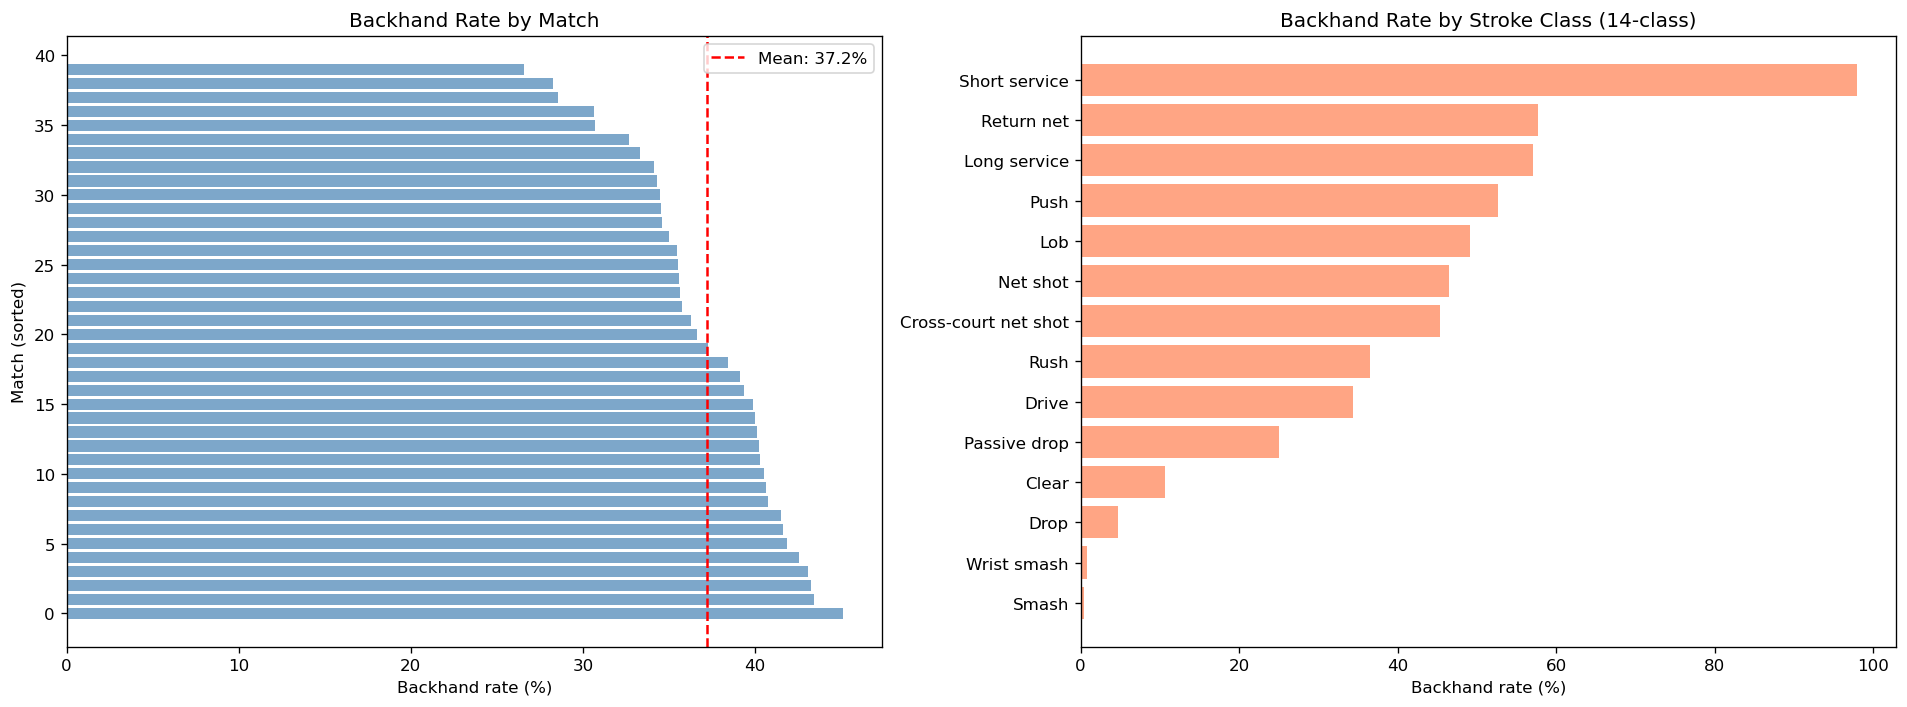

In [32]:
# Visualise backhand rate: by match + by class
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: by match (sorted)
axes[0].barh(range(len(backhand_by_match)), backhand_by_match.values, color='steelblue', alpha=0.7)
axes[0].axvline(backhand_by_match.mean(), color='red', ls='--', label=f'Mean: {backhand_by_match.mean():.1f}%')
axes[0].set_xlabel('Backhand rate (%)')
axes[0].set_ylabel('Match (sorted)')
axes[0].set_title('Backhand Rate by Match')
axes[0].legend()

# Right: by 14-class
bh_by_class = df[df['stroke_14'] != 'Unknown'].groupby('stroke_14')['backhand'].mean().sort_values(ascending=False) * 100
axes[1].barh(bh_by_class.index[::-1], bh_by_class.values[::-1], color='coral', alpha=0.7)
axes[1].set_xlabel('Backhand rate (%)')
axes[1].set_title('Backhand Rate by Stroke Class (14-class)')

plt.tight_layout()
plt.show()

In [35]:
# Check for match-level concentration: are any matches 0% or 100%?
print("Matches with <10% or >90% backhand rate:")
extreme = backhand_by_match[(backhand_by_match < 10) | (backhand_by_match > 90)]
if len(extreme) == 0:
    print("  None: all matches have a meaningful mix of forehand/backhand strokes.")
else:
    for m, r in extreme.items():
        print(f"  {m}: {r:.1f}%")

print(f"\nConclusion: backhand is present across ALL {len(backhand_by_match)} matches")
print(f"  with a narrow range ({backhand_by_match.min():.1f}%–{backhand_by_match.max():.1f}%).")
print(f"  This is NOT match-concentrated. No special split handling needed.")

Matches with <10% or >90% backhand rate:
  None: all matches have a meaningful mix of forehand/backhand strokes.

Conclusion: backhand is present across ALL 40 matches
  with a narrow range (26.6%–45.1%).
  This is NOT match-concentrated. No special split handling needed.


### Backhand Distribution Findings

**Class-concentrated (by design, not a problem):** Backhand rates vary by stroke type because that's how badminton works where short serves are almost always backhand, smashes almost never. This is signal, not noise.

**Not match-concentrated:** Every match has a meaningful mix of backhand/forehand strokes. The range across matches is narrow (27%–45%), with low coefficient of variation. No matches are extreme outliers. There's no annotation gap where some matches just didn't record backhand.

**Verdict:** The feature is clean. Fill nulls with 0, include in the feature set, no special handling needed for train/val/test splits. The model can learn the class-specific backhand patterns directly.

## 7. Train / Validation / Test Split

### Why match-level splitting
Strokes within the same rally are temporally dependent where each stroke is a response to the previous one. Random stroke-level splitting would leak rally context across partitions. We split at match level to eliminate this.

### Target ratio: 70 / 20 / 10

- **Val should be larger than test.** Val drives early stopping and epoch selection that's the signal that directly shapes model quality. A bigger val set means more reliable stopping decisions.
- **Test just needs to be large enough** for meaningful per-class evaluation. With 14 classes even 3,000 strokes gives usable metrics.
- Gender-stratified: split men's and women's matches separately to ensure representation in all partitions.

In [41]:
# Identify gender
WOMENS_PLAYERS = [
    'An_Se_Young', 'Carolina_Marin', 'Ratchanok', 'Pornpawee',
    'Pusarla', 'Mia_Blichfeldt', 'Evgeniya', 'Neslihan',
    'Supanida', 'Michelle_Li', 'Busanan'
]

matches = df['match'].unique().tolist()
df['gender'] = df['match'].apply(
    lambda x: 'Women' if any(p in x for p in WOMENS_PLAYERS) else 'Men'
)

mens_matches   = [m for m in matches if not any(p in m for p in WOMENS_PLAYERS)]
womens_matches = [m for m in matches if any(p in m for p in WOMENS_PLAYERS)]
print(f"Men's matches:   {len(mens_matches)}")
print(f"Women's matches: {len(womens_matches)}")

Men's matches:   29
Women's matches: 11


In [43]:
#  Gender-stratified split: 70/20/10
# Men's: 29 matches -> ~20 train / 6 val / 3 test
# Women's: 11 matches -> 8 train / 2 val / 1 test
# Total: ~28 train / 8 val / 4 test

# For men: test_size=0.30 -> 10 temp, then 70/30 -> 7 val / 3 test
train_m, temp_m = train_test_split(mens_matches, test_size=0.30, random_state=534)
val_m, test_m   = train_test_split(temp_m, test_size=0.30, random_state=534)

# For women: test_size=0.27 -> 3 temp, then 67/33 -> 2 val / 1 test
train_w, temp_w = train_test_split(womens_matches, test_size=0.27, random_state=534)
val_w, test_w   = train_test_split(temp_w, test_size=0.34, random_state=534)

train_matches = train_m + train_w
val_matches   = val_m + val_w
test_matches  = test_m + test_w

print(f"Split (matches):  Train {len(train_matches)} / Val {len(val_matches)} / Test {len(test_matches)}")

# Tag rows
df['split'] = 'unassigned'
df.loc[df['match'].isin(train_matches), 'split'] = 'train'
df.loc[df['match'].isin(val_matches),   'split'] = 'val'
df.loc[df['match'].isin(test_matches),  'split'] = 'test'

# Stroke counts
clean = df[df['stroke_14'] != 'Unknown']
split_counts = clean.groupby('split')['stroke_14'].count()
split_pcts   = (split_counts / split_counts.sum() * 100).round(1)

print(f"\nStroke distribution:")
for s in ['train', 'val', 'test']:
    if s in split_counts.index:
        print(f"  {s:>5}: {split_counts[s]:>6,} strokes ({split_pcts[s]}%)")

# Gender check
gender_split = df.groupby(['split', 'gender']).size().unstack(fill_value=0)
print(f"\nGender distribution:")
print(gender_split)

Split (matches):  Train 28 / Val 7 / Test 5

Stroke distribution:
  train: 23,249 strokes (72.2%)
    val:  4,813 strokes (14.9%)
   test:  4,142 strokes (12.9%)

Gender distribution:
gender    Men  Women
split               
test     3109   1147
train   19045   5128
val      4240    814


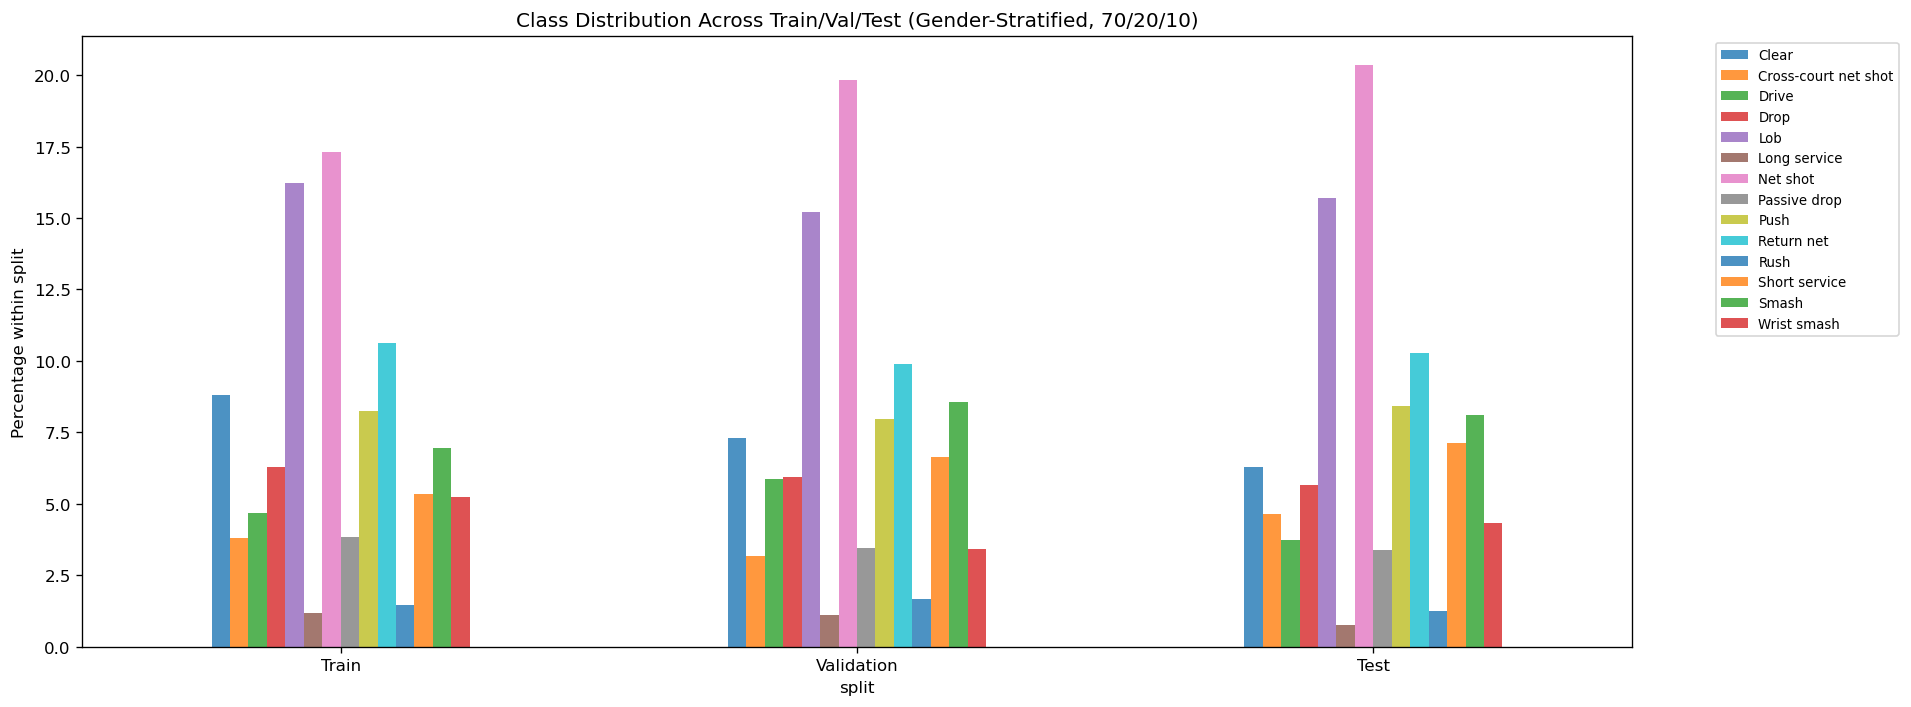

In [49]:
# Class distribution across splits
split_class     = clean.groupby(['split', 'stroke_14']).size().unstack(fill_value=0)
split_class_pct = split_class.div(split_class.sum(axis=1), axis=0) * 100

fig, ax = plt.subplots(figsize=(16, 6))
split_class_pct.loc[['train', 'val', 'test']].plot(kind='bar', ax=ax, alpha=0.8)
ax.set_ylabel('Percentage within split')
ax.set_title('Class Distribution Across Train/Val/Test (Gender-Stratified, 70/20/10)')
ax.set_xticklabels(['Train', 'Validation', 'Test'], rotation=0)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

In [50]:
# Compute max deviation per class between any two splits
print("Max class proportion deviation (percentage points):")
print(f"{'Class':<25} {'Train%':>7} {'Val%':>7} {'Test%':>7} {'MaxDev':>7}")
print("-" * 57)
for cls in split_class_pct.columns:
    vals = split_class_pct.loc[['train','val','test'], cls]
    dev  = vals.max() - vals.min()
    print(f"{cls:<25} {vals['train']:>6.1f}% {vals['val']:>6.1f}% {vals['test']:>6.1f}% {dev:>6.1f}pp")

Max class proportion deviation (percentage points):
Class                      Train%    Val%   Test%  MaxDev
---------------------------------------------------------
Clear                        8.8%    7.3%    6.3%    2.5pp
Cross-court net shot         3.8%    3.2%    4.6%    1.5pp
Drive                        4.7%    5.9%    3.7%    2.1pp
Drop                         6.3%    5.9%    5.7%    0.6pp
Lob                         16.2%   15.2%   15.7%    1.0pp
Long service                 1.2%    1.1%    0.8%    0.4pp
Net shot                    17.3%   19.8%   20.4%    3.0pp
Passive drop                 3.8%    3.4%    3.4%    0.5pp
Push                         8.3%    8.0%    8.4%    0.4pp
Return net                  10.6%    9.9%   10.3%    0.7pp
Rush                         1.5%    1.7%    1.3%    0.4pp
Short service                5.4%    6.6%    7.1%    1.8pp
Smash                        6.9%    8.6%    8.1%    1.6pp
Wrist smash                  5.2%    3.4%    4.3%    1.8pp


### Observations: Split Strategy
- Gender-stratified split ensures women's matches appear in all three partitions
- Targeting 70/20/10 gives val a larger stroke pool than test for more reliable early stopping
- With only 40 matches (after BST cleaning), exact percentages depend heavily on which specific matches land where; small deviations from target are expected and acceptable
- Net shot has the highest class deviation at 3.0pp, which is right at the 3pp threshold and acceptable given the constraints
- All other classes are under 2.5pp. Push is now 0.4pp (down from 4.7pp under RS=42)
- The split is reproducible via random_state=534

## 8. Class Imbalance Analysis

In [53]:
train_df     = df[(df['split'] == 'train') & (df['stroke_14'] != 'Unknown')]
train_counts = train_df['stroke_14'].value_counts()
total_train  = len(train_df)
n_classes    = len(train_counts)

# Inverse frequency weights (normalised so smallest weight = 1.0)
weights = total_train / (n_classes * train_counts)
weights_norm = (weights / weights.min()).round(2)

print("Class Weights (inverse frequency, normalised min=1.0):")
print(f"{'Class':<25} {'Train Count':>11} {'Weight':>8}")
print("-" * 47)
for cls in weights_norm.sort_values(ascending=False).index:
    print(f"{cls:<25} {train_counts[cls]:>11,} {weights_norm[cls]:>8.2f}")

print(f"\nTrain imbalance ratio: {train_counts.max()/train_counts.min():.0f}x")

Class Weights (inverse frequency, normalised min=1.0):
Class                     Train Count   Weight
-----------------------------------------------
Long service                      274    14.70
Rush                              338    11.91
Cross-court net shot              881     4.57
Passive drop                      892     4.51
Drive                           1,087     3.70
Wrist smash                     1,216     3.31
Short service                   1,244     3.24
Drop                            1,458     2.76
Smash                           1,614     2.50
Push                            1,919     2.10
Clear                           2,050     1.96
Return net                      2,473     1.63
Lob                             3,776     1.07
Net shot                        4,027     1.00

Train imbalance ratio: 15x


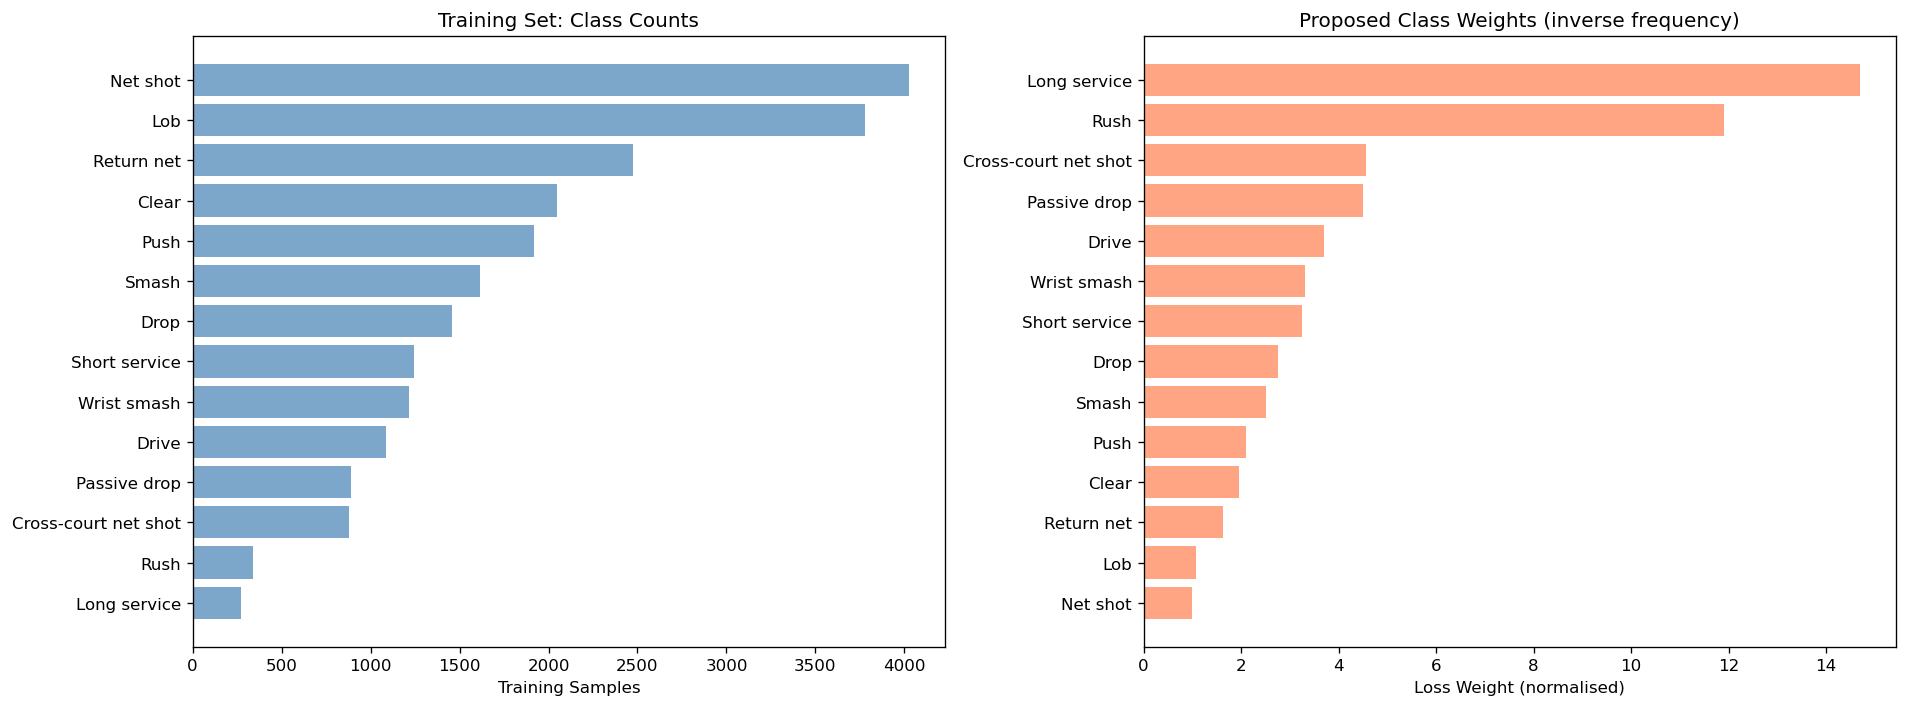

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].barh(train_counts.index[::-1], train_counts.values[::-1], color='steelblue', alpha=0.7)
axes[0].set_xlabel('Training Samples')
axes[0].set_title('Training Set: Class Counts')

sorted_w = weights_norm.sort_values()
axes[1].barh(sorted_w.index, sorted_w.values, color='coral', alpha=0.7)
axes[1].set_xlabel('Loss Weight (normalised)')
axes[1].set_title('Proposed Class Weights (inverse frequency)')

plt.tight_layout()
plt.show()

### Mitigation Strategies

**1. Class weighting in loss function (recommended first)**
Assign higher weights to underrepresented classes so the model is penalised more for misclassifying minority strokes. Simple to implement via `torch.nn.CrossEntropyLoss(weight=class_weights)`. No data duplication, widely used. Can cause training instability with very extreme ratios — monitor training loss.

**2. Focal loss (recommended alongside class weighting)**
Modified cross-entropy that down-weights easy examples and focuses on hard ones. Useful here because some minority classes (e.g. wrist smash vs smash) are also inherently ambiguous. Adds one hyperparameter (gamma) that needs tuning.

**3. Random oversampling (fallback)**
Duplicate minority class samples. Guarantees the model sees them more often, but risks overfitting to duplicated examples. Reserve this as a last resort.

**Recommendation:** Start with class weighting — minimal code, good baseline. If minority class F1 remains poor, layer in focal loss. Data augmentation (speed/trajectory variation, spatial flipping) is complementary but belongs in the preprocessing pipeline, not the loss function.

## 9. Export Split Assignments & Weights

In [57]:
# Save split assignments
split_map = df[['match', 'set_id', 'rally', 'ball_round', 'stroke_14', 'split',
                'aroundhead', 'backhand']].copy()
split_map = split_map[split_map['stroke_14'] != 'Unknown']
split_map.to_csv('shuttleset_splits.csv', index=False)
print(f"Saved {len(split_map):,} rows to shuttleset_splits.csv")

# Save class weights
weight_dict = weights_norm.to_dict()
with open('class_weights.json', 'w') as f:
    json.dump(weight_dict, f, indent=2)
print(f"Saved {len(weight_dict)} class weights to class_weights.json")

Saved 32,204 rows to shuttleset_splits.csv
Saved 14 class weights to class_weights.json


## 10. ShuttleSet Paper: Annotation Quality & Caveats

Summary of findings from Wang et al. (2023), *"ShuttleSet: A Human-Annotated Stroke-Level Singles
Dataset for Badminton Tactical Analysis"* (KDD '23) that the team should be aware of.

### Annotation process
- Annotated by **6 dedicated annotators with badminton knowledge** using the S² labeling tool
- Labeling follows a 7-step per-stroke cycle: hitting time -> hitter location -> opponent location -> backhand/aroundhead/height -> opponent return time -> landing location -> shot type
- Rallies are randomly sampled for quality checking after annotation
- Fool-proof UI design to catch unintended clicking errors

### Inter-annotator agreement / consistency check
The paper re-labeled **3 matches** to measure annotation consistency:

| Category | Metric | Score |
|----------|--------|-------|
| Temporal — serve timing | MAE (frames) | 0.24 |
| Temporal — return timing | MAE (frames) | 0.02 |
| Temporal — dead bird timing | MAE (frames) | 0.00 |
| Spatial — shuttle position | MAE (grid units) | 0.18 |
| Spatial — player position | MAE (grid units) | 0.86 |
| Shot type — serve | Accuracy difference | 0.00 |
| Shot type — return | Accuracy difference | 0.05 |
| Shot type — dead bird | Accuracy difference | 0.11 |

**Key takeaway:** Temporal annotation is very tight (sub-frame). Shuttle position is precise (0.18 MAE). **Player position is the noisiest field** at 0.86 MAE meaning roughly one grid cell of error on average. Shot type labeling is solid for serves (perfect) and returns (95% agreement) but has 11% disagreement on dead bird strokes (rally-ending shots), which are inherently ambiguous (e.g., was that a failed drop or a net shot?).

### Implications for our project

**Player position features (`player_location_x/y`, `opponent_location_x/y`):** These are the least reliable spatial fields. If we use player positions as input features, we should expect some noise. This is another argument for the model learning to be robust to position jitter — dropout or small Gaussian noise augmentation on position features could help.

**Dead bird shot type labels:** 11% disagreement means 1 in 9 rally-ending stroke labels may be debatable. Since rally-ending strokes are a significant fraction of the data, this is non-trivial noise in our target labels. Worth monitoring whether the model struggles disproportionately on final-stroke predictions.

**No pre-defined splits:** The paper explicitly states they do *not* provide fixed train/val/test splits — this is by design to allow flexibility for different tasks. Our match-level gender-stratified split is a reasonable choice that the paper's authors would endorse.

### Context window — what the paper's benchmarks use

The paper evaluates stroke forecasting and movement forecasting at three encoding lengths: **τ = 8, 4, and 2 strokes**. These are the number of *given* (observed) strokes before the model predicts future ones.

This is relevant to our window size discussion:
- The BST paper uses 3 strokes + time offset
- The ShuttleSet paper benchmarks at 2, 4, and 8 — all work, with modest performance differences
- ShuttleNet's shot type CE is fairly stable across τ = 2, 4, 8 (2.39–2.41), suggesting the model doesn't gain much from longer context
- This supports defaulting to a small window (3 strokes per BST) and not over-engineering it

### Gender-specific distributions from the paper (Table 1)

The paper breaks down shot type counts by men's vs women's singles. Notable differences:
- **Long service:** Women use it almost as much as men (172 vs 183) — it's 0.70% of all strokes for women vs 0.75% for men. This is the most gender-balanced class proportionally.
- **Driven flight:** 43 men's, **0 women's** — this class literally doesn't exist in women's matches. After the 14-class collapse it folds into Drive, but worth noting.
- **Net shot:** Men's singles has 3,781 (15.45%) vs women's 527 (2.15%). The raw count difference is large but proportional to the overall men/women stroke ratio (3:1).

The gender breakdown reinforces why gender-stratified splitting matters: the class distribution *within* women's matches differs from men's. If all women's matches landed in one partition, that partition's class proportions would shift.

## Summary of Key Findings

| Finding | Detail |
|---------|--------|
| Dataset version | **BST-cleaned** (4 matches excluded, 5 shots removed) |
| Total strokes (cleaned) | 33,483 across 40 matches (29 men's, 11 women's) |
| Unknown labels | 1,279 (3.8%) excluded from training |
| Non-serve rally starts | 1,143 total; 1,125 are Unknown (annotation gaps), 18 real edge cases |
| Missing hit coordinates | 12.8% of strokes |
| `aroundhead` nulls | Confirmed boolean False (fill with 0). 9.6% are around-the-head |
| `backhand` nulls | Confirmed boolean False (fill with 0). 37.5% backhand, all matches |
| 18-class imbalance ratio | 112x (Net shot 5,824 vs Driven flight 52) |
| 14-class imbalance ratio | 16x (Net shot 5,824 vs Long service 359) |
| Train imbalance ratio | 15x (Net shot 4,027 vs Long service 274) |
| Split (gender-stratified, RS=534) | 72.2% train / 14.9% val / 12.9% test by strokes |
| Max class deviation | 3.0pp (Net shot), all others under 2.5pp |
| Val gender skew | 814 women's strokes (16.1%), up from 599 (12.2%) under RS=42 |
| Recommended imbalance fix | Class weighting -> Focal loss -> Oversampling |
| Annotation noise (paper) | Player position MAE 0.86 grids; dead bird shot type 11% disagreement |
| Driven flight | 0 instances in women's matches, collapses into Drive at 14-class |

### Open Items
1. Investigate the 18 non-Unknown non-serve rally starts (annotation errors or lets?)
2. Window size: default to BST's 3-stroke convention, ablate during model tuning if needed
3. Consider noise augmentation on player position features given 0.86 MAE annotation noise
4. Monitor model performance on rally-ending strokes given 11% label disagreement